In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_BCICIV import load_all_subjects
from src.train_EEGNet import train_model_cv
import torch
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import mlflow

np.random.seed(42)
torch.manual_seed(42)


/home/alumno/Desktop/datos/nn/EEGNet-Motor-Imagery-BCI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DATA LOAD

In [2]:
data_path = '../datasets/BCICIV_2a_gdf'

data_22 = load_all_subjects(data_path, channels_to_use='all')
data_22_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)], channels_to_use='all')
data_11 = load_all_subjects(data_path)
data_11_multiband = load_all_subjects(data_path, use_multiband=True, bands=[(8, 12), (13, 30)])

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A01T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A02T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A08T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loaded file: ../datasets/BCICIV_2a_gdf/A09T.gdf


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/alumno/.local/share/uv/python/cpython-3.13.7-l

In [3]:
subjects = data_22['subject_ids'] 

X_22 = data_22['X'] 
y_22 = data_22['y'] 

X_22_multiband = data_22_multiband['X'] 
y_22_multiband = data_22_multiband['y'] 

X_11 = data_11['X'] 
y_11 = data_11['y'] 

X_11_multiband = data_11_multiband['X'] 
y_11_multiband = data_11_multiband['y'] 

In [4]:
models = {
    'model': [],
    'accuracies': [],
    'name': []
}

# Tests with 22 channels

## 22 channels (raw + normalization)

In [5]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=[], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_22')

2026/03/24 09:20:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/24 09:20:13 INFO mlflow.store.db.utils: Updating database tables
2026/03/24 09:20:15 INFO mlflow.tracking.fluent: Experiment with name 'BCI_EEGNet' does not exist. Creating a new experiment.
2026/03/24 09:21:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:21:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9123 | Test Acc: 0.7413


2026/03/24 09:21:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:22:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:22:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9191 | Test Acc: 0.5347


2026/03/24 09:22:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:23:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:23:58 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9130 | Test Acc: 0.7222


2026/03/24 09:30:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:31:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:31:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 9 | Subject A09 | Train Acc: 0.9217 | Test Acc: 0.5417


2026/03/24 09:31:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6477 ± 0.0690


## 22 channels + laplacian filter on C3 and C4

In [6]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22')

2026/03/24 09:32:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:32:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9079 | Test Acc: 0.7832


2026/03/24 09:32:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:34:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:34:05 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9217 | Test Acc: 0.5278


2026/03/24 09:34:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:35:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:35:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9200 | Test Acc: 0.6944


2026/03/24 09:41:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:42:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:42:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 9 | Subject A09 | Train Acc: 0.9348 | Test Acc: 0.5417


2026/03/24 09:42:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6531 ± 0.0840


## 22 channels - only mu band

In [7]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'mu_band'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_22')

2026/03/24 09:44:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:44:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8818 | Test Acc: 0.6434


2026/03/24 09:44:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:45:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:45:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.8774 | Test Acc: 0.4375


2026/03/24 09:45:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:46:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:46:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.8617 | Test Acc: 0.7014


2026/03/24 09:52:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:54:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.8757 | Test Acc: 0.4722


2026/03/24 09:54:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 09:54:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5921 ± 0.0863


## 22 channels - mu + beta band

In [8]:
model, test_subject_accuracies = train_model_cv(X_22_multiband, y_22_multiband, subjects, transforms=['laplacian', 'multiband'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_22')

2026/03/24 09:56:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:56:23 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9305 | Test Acc: 0.7273


2026/03/24 09:56:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 09:58:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 09:58:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9374 | Test Acc: 0.5069


2026/03/24 09:58:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:01:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:01:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9322 | Test Acc: 0.7222


2026/03/24 10:13:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:15:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9374 | Test Acc: 0.4792


2026/03/24 10:15:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:15:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6261 ± 0.0875


# Tests with 11 channels

## 11 channels (raw + normalization)

In [9]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=[], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('raw_11')

2026/03/24 10:16:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:16:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9192 | Test Acc: 0.7133


2026/03/24 10:16:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:17:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:17:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9130 | Test Acc: 0.5069


2026/03/24 10:17:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:17:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:17:52 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9130 | Test Acc: 0.7014


2026/03/24 10:22:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:22:11 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:22:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9270 | Test Acc: 0.5278


2026/03/24 10:22:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:23:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6314 ± 0.0713


## 11 channels + laplacian filter on C3 and C4

In [10]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_11')

2026/03/24 10:23:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:23:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9183 | Test Acc: 0.7762


2026/03/24 10:23:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:24:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:24:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9252 | Test Acc: 0.5625


2026/03/24 10:24:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:25:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:25:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9122 | Test Acc: 0.6458


2026/03/24 10:30:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:30:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:31:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9339 | Test Acc: 0.5486


2026/03/24 10:31:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:31:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6624 ± 0.0749


## 11 channels - only mu band

In [11]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'mu_band'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('mu_11')

2026/03/24 10:31:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:31:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.8758 | Test Acc: 0.5804


2026/03/24 10:32:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:32:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:32:53 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.8939 | Test Acc: 0.4583


2026/03/24 10:32:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:33:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:33:48 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.8652 | Test Acc: 0.6389


2026/03/24 10:38:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:38:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:39:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.8948 | Test Acc: 0.4583


2026/03/24 10:39:11 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:39:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.5974 ± 0.1007


## 11 channels - mu + beta band

In [12]:
model, test_subject_accuracies = train_model_cv(X_11_multiband, y_11_multiband, subjects, transforms=['laplacian', 'multiband'], epochs=100, lr=0.0003, patience=20)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('multiband_11')

2026/03/24 10:40:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:40:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.9296 | Test Acc: 0.7413


2026/03/24 10:40:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:41:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:41:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.9417 | Test Acc: 0.5000


2026/03/24 10:41:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:43:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:43:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.9330 | Test Acc: 0.6875


2026/03/24 10:49:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:49:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:50:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.9391 | Test Acc: 0.4861


2026/03/24 10:50:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 10:50:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6446 ± 0.0914


# Data Augmentation

## 22 channels + laplace + data augmentation

### 100 Epochs

In [13]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug')

Early stopping in epoch 78. Best train loss: 0.6007


2026/03/24 10:51:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 10:51:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.6447 | Test Acc: 0.7762


2026/03/24 10:52:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 10:53:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 10:53:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 2 | Subject A02 | Train Acc: 0.6870 | Test Acc: 0.4514


...

Fold 8 | Subject A08 | Train Acc: 0.6643 | Test Acc: 0.7569


2026/03/24 11:01:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 11:01:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 11:02:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.6896 | Test Acc: 0.5139


2026/03/24 11:02:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 11:02:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6192 ± 0.0976


### 400 Epochs

In [14]:
model, test_subject_accuracies = train_model_cv(X_22, y_22, subjects, transforms=['laplacian'], epochs=400, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug_400')

Early stopping in epoch 144. Best train loss: 0.5430


2026/03/24 11:04:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 11:04:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.6751 | Test Acc: 0.7552


2026/03/24 11:04:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping in epoch 179. Best train loss: 0.5200


...

Early stopping in epoch 109. Best train loss: 0.5492


2026/03/24 11:19:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.6870 | Test Acc: 0.4931


2026/03/24 11:19:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 11:19:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6307 ± 0.0814


## 11 channels + laplace + data augmentation

### 100 Epochs

In [15]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], epochs=100, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug')

2026/03/24 11:20:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  
2026/03/24 11:20:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.6629 | Test Acc: 0.7483


2026/03/24 11:20:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                           

Early stopping in epoch 96. Best train loss: 0.5587


2026/03/24 11:21:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 11:21:25 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


...

Fold 8 | Subject A08 | Train Acc: 0.6626 | Test Acc: 0.6736


2026/03/24 11:26:58 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 11:27:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/24 11:27:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.  


Fold 9 | Subject A09 | Train Acc: 0.6687 | Test Acc: 0.5694


2026/03/24 11:27:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 11:27:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6816 ± 0.0956


### 400 Epochs

In [17]:
model, test_subject_accuracies = train_model_cv(X_11, y_11, subjects, transforms=['laplacian'], epochs=400, lr=0.0003, patience=20, augment=True)
models['model'].append(model)
models['accuracies'].append(test_subject_accuracies)
models['name'].append('laplacian_22_aug_400')

Early stopping in epoch 141. Best train loss: 0.5458


2026/03/24 11:30:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 11:30:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Fold 1 | Subject A01 | Train Acc: 0.6855 | Test Acc: 0.7832


2026/03/24 11:30:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
                                                                                                            

Early stopping in epoch 144. Best train loss: 0.5449


...

Early stopping in epoch 121. Best train loss: 0.5382


2026/03/24 11:39:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 9 | Subject A09 | Train Acc: 0.6904 | Test Acc: 0.5486


2026/03/24 11:39:41 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/24 11:39:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Mean Subject Test Accuracy: 0.6654 ± 0.1008


# Visualization

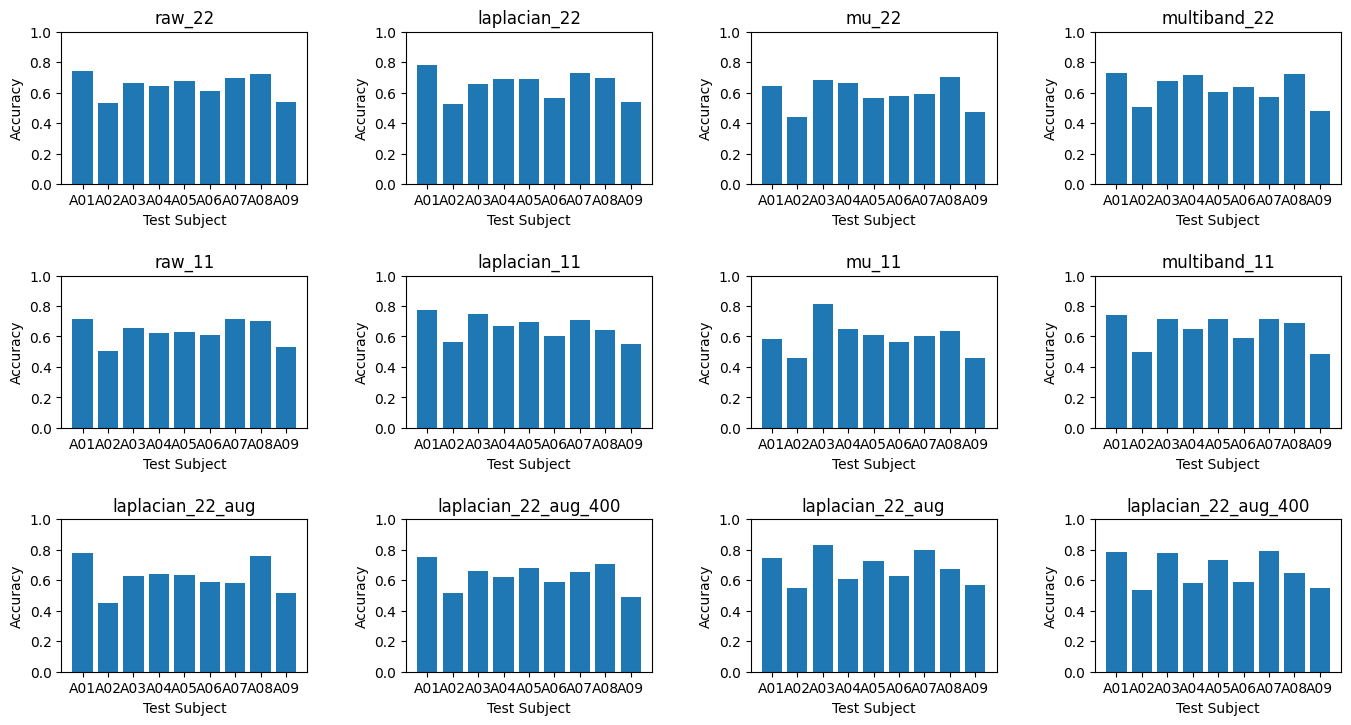

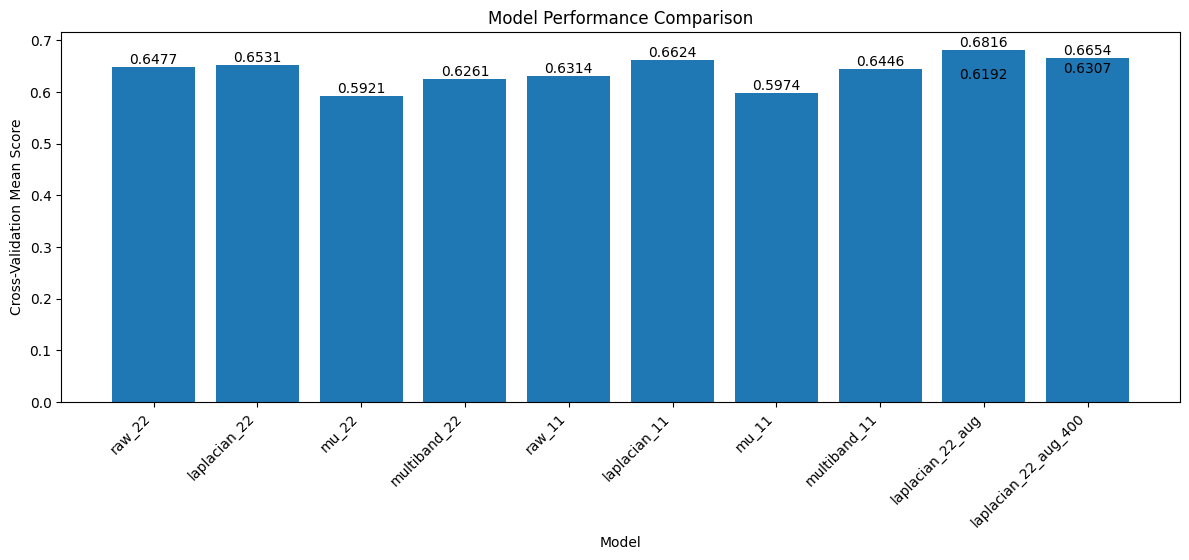

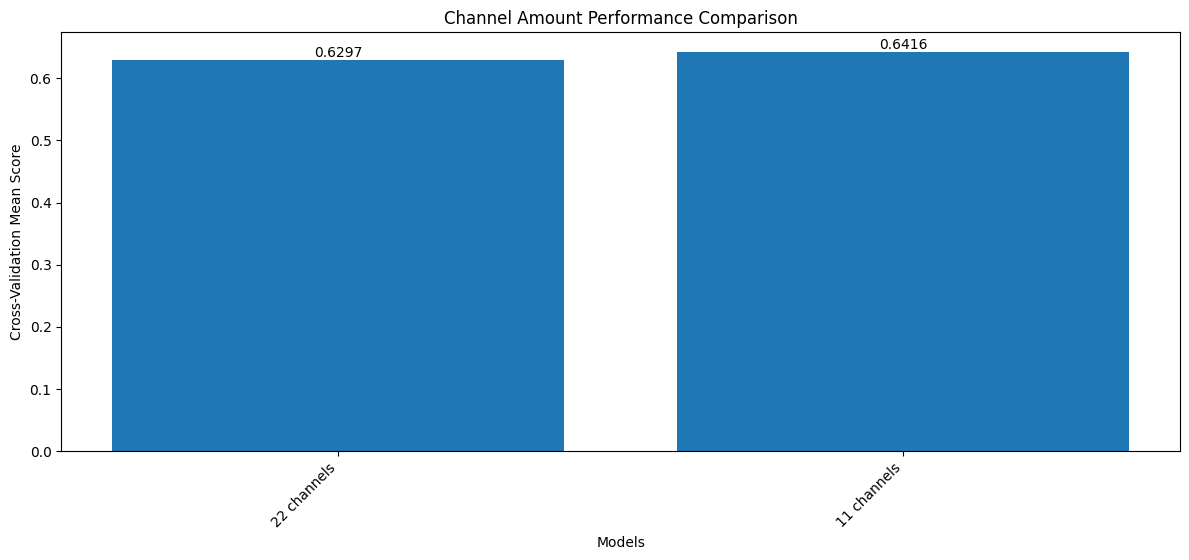

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 8))

for i, (name, accuracies) in enumerate(zip(models['name'], models['accuracies'])):
    ax = axes[i // 4, i % 4]
    ax.bar(np.unique(subjects), accuracies)
    ax.set_title(name)
    ax.set_xlabel('Test Subject')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.6)

plt.savefig("../figures/accuracy_per_subject.png")
mlflow.log_artifact("../figures/accuracy_per_subject.png")


accs = [] 

for acc in models['accuracies']:
    accs.append(np.mean(acc))

plt.figure(figsize=(12, 6))
bars = plt.bar(models['name'], accs)
plt.xlabel('Model')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Model Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)
plt.savefig("../figures/mean_accuracies.png")
mlflow.log_artifact("../figures/mean_accuracies.png")


acc_11_ch = np.mean(accs[4:8])
acc_22_ch = np.mean(accs[:4])

plt.figure(figsize=(12, 6))
bars = plt.bar(['22 channels', '11 channels'], [acc_22_ch, acc_11_ch])
plt.xlabel('Models')
plt.ylabel('Cross-Validation Mean Score')
plt.title('Channel Amount Performance Comparison')
plt.bar_label(bars, fmt="%.4f")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95],)
plt.savefig("../figures/mean_accuracies_per_channel_amount.png")
mlflow.log_artifact("../figures/mean_accuracies_per_channel_amount.png")